In [2]:
import pandas as pd
import random

positive_templates = [
    "The mentors were very supportive and helpful.",
    "I gained valuable industry experience.",
    "The internship provided excellent learning oppurtunities.",
    "The work environment was very professional and welcoming.",
    "I learned many new technical skills.",
    "The team was collaborative and encouraging.",
    "I enjoyed working on real-world projects.",
    "The supervisors provided constructive feedback.",
    "This internship exceeded my expectations.",
    "The training sessions were highly informative."
]

negative_templates = [
    "The workload was overwhelming and stressful.",
    "I received very little guidance from my supervisor.",
    "Communication within the team was poor.",
    "The internship lacked proper structure.",
    "The training sessions were unorganized.",
    "The tasks assigned were repetitive and boring.",
    "I did not receive enough feedback on my work.",
    "The expectations were unclear throughout the internship.",
    "There were limited opportunities to learn new skills.",
    "The overall experience was disappointing."
]

neutral_templates = [
    "The internship experience was average overall.",
    "The assigned tasks were manageable.",
    "The internship met the basic requirements.",
    "The work environment was acceptable.",
    "The responsibilities were as expected.",
    "The training provided was adequate.",
    "The internship was neither exceptional nor poor.",
    "I completed the assigned tasks successfully.",
    "The experience was fairly standard.",
    "The support provided was sufficient."
]

dataset = []

# 200 Positive
for _ in range(200):
    dataset.append([
        random.choice(positive_templates),
        "Positive"
    ])

# 200 Negative
for _ in range(200):
    dataset.append([
        random.choice(negative_templates),
        "Negative"
    ])

# 100 Neutral
for _ in range(100):
    dataset.append([
        random.choice(neutral_templates),
        "Neutral"
    ])

random.shuffle(dataset)

df = pd.DataFrame(dataset, columns=["feedback", "sentiment"])

df.to_csv("intern_feedback_500.csv", index=False)

print("Dataset created successfully!")
print("Shape:", df.shape)

df.head()

Dataset created successfully!
Shape: (500, 2)


,feedback,sentiment
0,The internship met the basic requirements.,Neutral
1,The overall experience was disappointing.,Negative
2,The internship lacked proper structure.,Negative
3,The work environment was very professional and...,Positive
4,The tasks assigned were repetitive and boring.,Negative


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("intern_feedback_500.csv")

print(df.shape)
df.head()

(500, 2)


,feedback,sentiment
0,The internship met the basic requirements.,Neutral
1,The overall experience was disappointing.,Negative
2,The internship lacked proper structure.,Negative
3,The work environment was very professional and...,Positive
4,The tasks assigned were repetitive and boring.,Negative


In [5]:
print(df.info())

print(df['sentiment'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   feedback   500 non-null    object
 1   sentiment  500 non-null    object
dtypes: object(2)
memory usage: 7.9+ KB
None
sentiment
Negative    200
Positive    200
Neutral     100
Name: count, dtype: int64


In [6]:
X = df["feedback"]

y = df["sentiment"]

In [7]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_vectorized = vectorizer.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [10]:
y_pred = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 100.0 %


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        40
     Neutral       1.00      1.00      1.00        20
    Positive       1.00      1.00      1.00        40

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



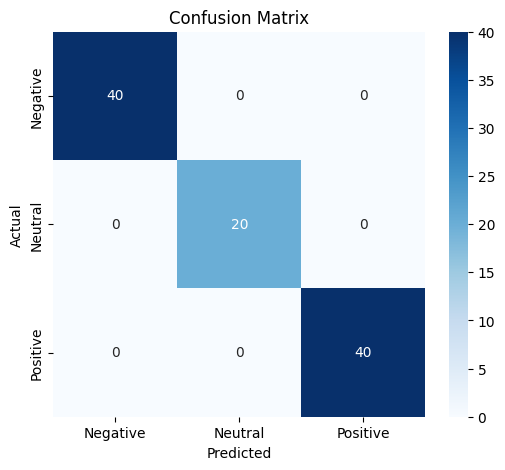

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

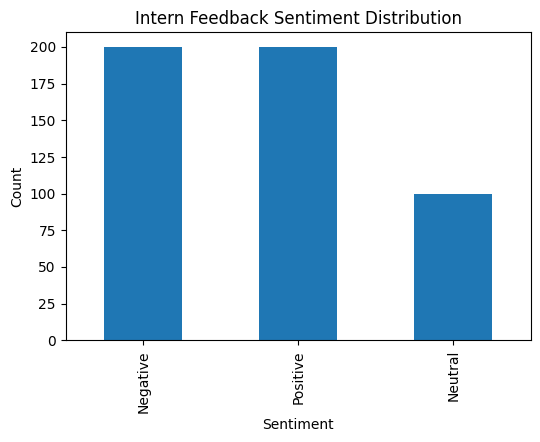

In [14]:
plt.figure(figsize=(6,4))

df['sentiment'].value_counts().plot(
    kind='bar'
)

plt.title("Intern Feedback Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [15]:
new_feedback = [
    "The mentors were extremely supportive and I learned many new skills."
]

new_vector = vectorizer.transform(new_feedback)

prediction = model.predict(new_vector)

print("Sentiment:", prediction[0])

Sentiment: Positive


In [16]:
samples = [

    "The internship was amazing and the team was very supportive.",

    "The workload was excessive and communication was poor.",

    "The internship met my expectations."
]

sample_vectors = vectorizer.transform(samples)

predictions = model.predict(sample_vectors)

for feedback, sentiment in zip(samples, predictions):

    print("Feedback:", feedback)

    print("Predicted Sentiment:", sentiment)

    print("-"*50)

Feedback: The internship was amazing and the team was very supportive.
Predicted Sentiment: Positive
--------------------------------------------------
Feedback: The workload was excessive and communication was poor.
Predicted Sentiment: Negative
--------------------------------------------------
Feedback: The internship met my expectations.
Predicted Sentiment: Negative
--------------------------------------------------


In [17]:
import pickle

pickle.dump(
    model,
    open("sentiment_model.pkl","wb")
)

pickle.dump(
    vectorizer,
    open("tfidf_vectorizer.pkl","wb")
)

print("Model saved successfully")

Model saved successfully
